In [1]:
import carla
import time
from math import *
import random
client = carla.Client('localhost', 2000)
world = client.get_world()
map = world.get_map()
spawn_point = map.get_spawn_points()[0]

In [2]:
world.get_map().name

'Carla/Maps/Town02'

In [26]:
spectator = world.get_spectator()
spectator.set_transform(spawn_point)

In [4]:

vehicle_blueprint= world.get_blueprint_library().filter("*.nissan.*")

vehicle = world.try_spawn_actor(vehicle_blueprint[0], spawn_point)

if vehicle == None:
    
    vehicle = world.get_actors().filter("vehicle.*")
    for v in vehicle:
        v.destroy()

world.wait_for_tick()

vehicle_position = vehicle.get_transform()
print(vehicle_position)



Transform(Location(x=-7.530000, y=142.190002, z=0.478947), Rotation(pitch=0.000000, yaw=89.999954, roll=0.000000))


In [113]:
print(vehicle.get_transform())

Transform(Location(x=7.433792, y=139.537354, z=0.310294), Rotation(pitch=-0.367949, yaw=-27.686451, roll=-1.209351))


In [5]:
vehicle.set_transform(spawn_point)

In [103]:
vehicle.set_transform()

ArgumentError: Python argument types in
    Actor.set_transform(Vehicle)
did not match C++ signature:
    set_transform(class carla::client::Actor {lvalue}, class carla::geom::Transform transform)

In [5]:
def PID_speed(vehicle : carla.Vehicle, target_speed : float, previous_error : float ,previous_int : float, delta_time : float):
    kp = 0.2
    ki = 0.02
    kd = 0.02
    brake = 0.0
    current_speed = vehicle.get_velocity().length()
    error = target_speed - current_speed
    prop_term = kp * error
    int_term = (previous_int + error * delta_time)
    int_term_ki = int_term * ki
    deriv_term = kd * (error - previous_error) / delta_time if delta_time > 0 else 0
    control_signal = prop_term + int_term_ki + deriv_term
    
    control_signal = max(-1 ,min(control_signal,1))

    if control_signal < 0:
        brake = -1 * control_signal
        control_signal = 0

    return control_signal, brake, error, int_term

In [6]:
def steering_angle(Current_position : carla.Transform, Goal : carla.Transform):
    # Relative vector from Car to Goal
    relative_vector = carla.Vector2D(Goal.location.x - Current_position.location.x, Goal.location.y - Current_position.location.y)
    
    #Rotation Matrix
    Rotation_matrix = [[cos(radians(-Current_position.rotation.yaw)), -sin(radians(-Current_position.rotation.yaw))],
                       [sin(radians(-Current_position.rotation.yaw)), cos(radians(-Current_position.rotation.yaw))]]
    
    # Rotated vector in order with Car
    rotated_relative_vector = carla.Vector2D(Rotation_matrix[0][0] * relative_vector.x + Rotation_matrix[0][1] * relative_vector.y,
                                            Rotation_matrix[1][0] * relative_vector.x + Rotation_matrix[1][1] * relative_vector.y)
    
    Ld2 = rotated_relative_vector.squared_length()
    curvature = (2 * rotated_relative_vector.y) / Ld2
    angle = degrees(atan(3 * curvature))
    
    
    print(f"rotated_relative_vector: {rotated_relative_vector}")
    print(f"rotated_relative_vector.y: {rotated_relative_vector.y}")
    print(f"curvature: {curvature}")

    return angle

def Pure_pursuit(vehicle : carla.Vehicle, Goal : carla.Transform):

    Next_goal = Goal
    Current_position = vehicle.get_transform()

    Angle = steering_angle(Current_position, Next_goal)
    
    return Angle

In [35]:
def Calc_Adaptive_Speed(P1 : carla.Location, P2 : carla.Location, P3 : carla.Location, Max_speed : float = 20):
    v1 = carla.Vector2D(P2.x - P1.x, P2.y - P1.y)
    v2 = carla.Vector2D(P3.x - P2.x, P3.y - P2.y)
    dot = v1.x * v2.x + v1.y * v2.y
    denom = v1.length() * v2.length()

    cos_theta = dot / denom
    cos_theta = max(-1.0, min(1.0, cos_theta))

    Theta = max(1,degrees(acos(cos_theta))*0.05)
    print(f"theta = {Theta}")
    print(f"Adjusted speed = {1/(Theta) * Max_speed}")
    
    return 1/(Theta) * Max_speed
    

In [19]:
def Make_Path(vehicle : carla.Vehicle, length : int, lookahead : float):
    Path = [map.get_waypoint(vehicle.get_transform().location)]
    while len(Path) < length:
        Next_waypoints = Path[len(Path)-1].next(lookahead)
        Path.append(Next_waypoints[random.randint(0,len(Next_waypoints)-1)])
    return Path

In [33]:
list_of_throttle = []

In [34]:
# Reset Vehicle


vehicle.set_transform(spawn_point)
vehicle.apply_control(carla.VehicleControl(throttle=0.0, steer=0))
world.wait_for_tick()
print(vehicle.get_wheel_steer_angle(carla.VehicleWheelLocation.FL_Wheel))
print(vehicle.get_wheel_steer_angle(carla.VehicleWheelLocation.FR_Wheel))

0.0
0.0


In [36]:
# Initializing Parameters for PID controller
error = 0
integral = 0
delta_time = 0
OverAll_time = 0
Max_speed = 15
LookAhead = 10
waypoints = 10
Path = Make_Path(vehicle,LookAhead,waypoints)
new_point = Path[0]


# Drawing Debug Point
world.debug.draw_point(new_point.transform.location + carla.Vector3D(0,0,1), size=0.2, color=carla.Color(0,255, 0), life_time=10.0)

while True:

    # Euclidean distance between the vehicle and the goal point
    dx = new_point.transform.location.x - vehicle.get_transform().location.x
    dy = new_point.transform.location.y - vehicle.get_transform().location.y
    dist = (dx*dx + dy*dy) ** 0.5
    
    if dist < 7:
        world.debug.draw_point(new_point.transform.location + carla.Vector3D(0,0,1), size=0.2, color=carla.Color(255, 0, 0), life_time=10.0)
        
        Path.remove(Path[0])
        
        if len(Path) < 3:
            Path = Make_Path(vehicle,waypoints,LookAhead)
        new_point = Path[0]

        world.debug.draw_point(new_point.transform.location + carla.Vector3D(0,0,1), size=0.2, color=carla.Color(0,255, 0), life_time=10.0)
    
    
    Target_speed = Calc_Adaptive_Speed(vehicle.get_location(),Path[0].transform.location,Path[1].transform.location,Max_speed)
    
    
    # Steering Control using Pure Pursuit
    Steerangle = Pure_pursuit(vehicle, new_point.transform)
    Angle = Steerangle / 70 
    
    
    
    # Throttle Control using PID Controller
    throttle, brake, error, integral = PID_speed(vehicle, Target_speed, error, integral, delta_time)
    

    vehicle.apply_control(carla.VehicleControl(throttle=throttle, steer=Angle, brake=brake))

    
    # Debug Information
    print(f"Vehicle Location: {vehicle.get_transform().location}")
    print(f"Goal_Point: {new_point.transform.location}")
    print(f"required Steering wheel angle: {Steerangle}")
    print(f"Throttle: {throttle}")
    current_speed = vehicle.get_velocity().length()
    list_of_throttle.append([current_speed,throttle + brake ,Steerangle,OverAll_time])
    
    
    snap_shot = world.wait_for_tick()
    delta_time = snap_shot.timestamp.delta_seconds
    OverAll_time += delta_time



theta = 1
Adjusted speed = 15.0
rotated_relative_vector: Vector2D(x=10.000313, y=-0.071859)
rotated_relative_vector.y: -0.07185942679643631
curvature: -0.0014370244104448368
Vehicle Location: Location(x=-7.532022, y=142.665268, z=0.200828)
Goal_Point: Location(x=-7.438930, y=152.665405, z=0.000000)
required Steering wheel angle: -0.24700477111130498
Throttle: 1
theta = 1
Adjusted speed = 15.0
rotated_relative_vector: Vector2D(x=10.000191, y=-0.071857)
rotated_relative_vector.y: -0.0718570202589035
curvature: -0.0014370113644694533
Vehicle Location: Location(x=-7.532022, y=142.665390, z=0.200664)
Goal_Point: Location(x=-7.438930, y=152.665405, z=0.000000)
required Steering wheel angle: -0.247002528714993
Throttle: 1
theta = 1
Adjusted speed = 15.0
rotated_relative_vector: Vector2D(x=9.999809, y=-0.071844)
rotated_relative_vector.y: -0.07184431701898575
curvature: -0.0014368669368879066
Vehicle Location: Location(x=-7.532019, y=142.665771, z=0.200596)
Goal_Point: Location(x=-7.438930, y=

KeyboardInterrupt: 

In [ ]:
vehicle.destroy()


True

In [98]:
print(list_of_throttle[-1])


[16.269004821777344, 1.0, -1.5626111250532608, 23.754995055496693]


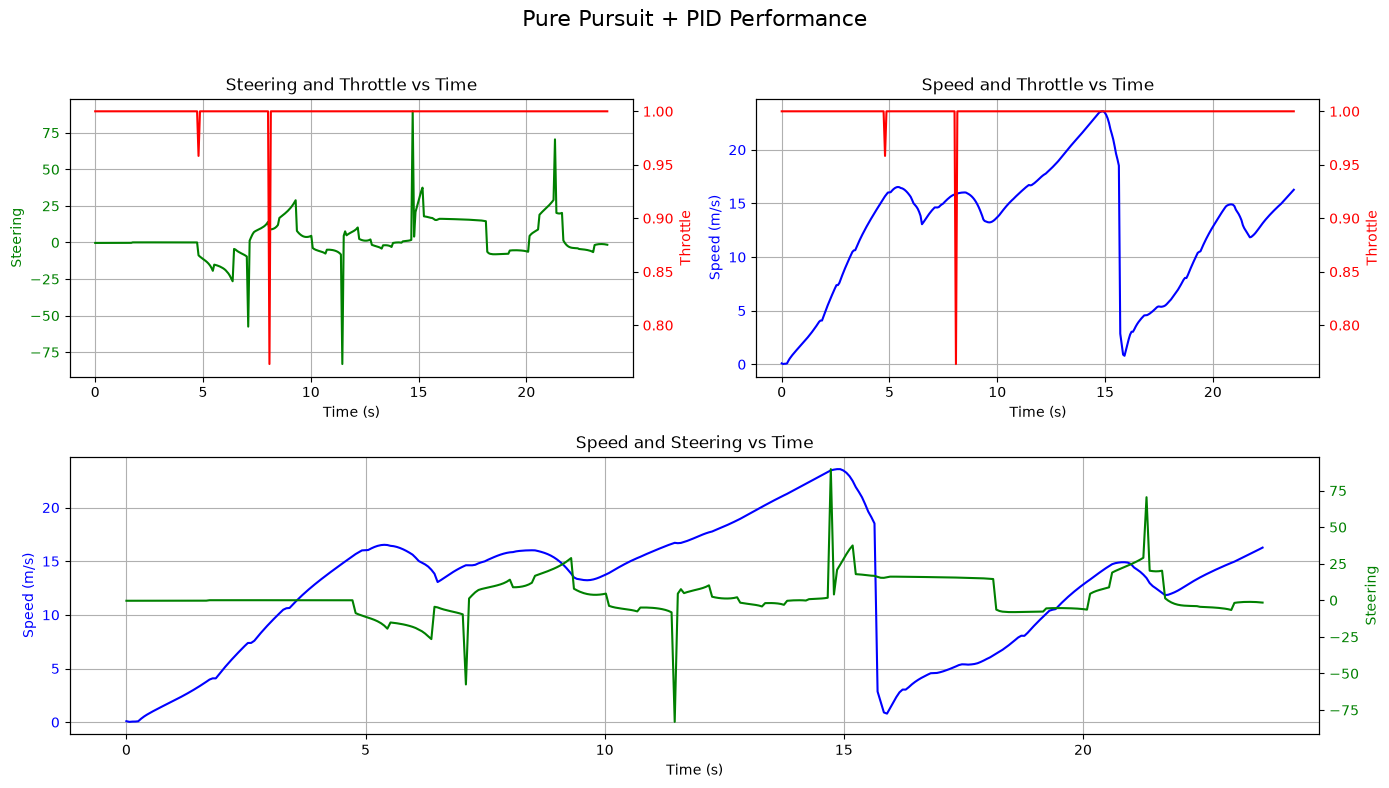

: 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Data format:
# [speed, throttle, steering, time]

times      = [x[3] for x in list_of_throttle]
speeds     = [x[0] for x in list_of_throttle]
throttles  = [x[1] for x in list_of_throttle]
steerings  = [x[2] for x in list_of_throttle]

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 2, figure=fig)

# ============================================================
# Steering + Throttle
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(times, steerings, 'g', label='Steering')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Steering", color='g')
ax1.tick_params(axis='y', labelcolor='g')
ax1.grid(True)

ax1_t = ax1.twinx()
ax1_t.plot(times, throttles, 'r', label='Throttle')
ax1_t.set_ylabel("Throttle", color='r')
ax1_t.tick_params(axis='y', labelcolor='r')

ax1.set_title("Steering and Throttle vs Time")

# ============================================================
# Speed + Throttle
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])

ax2.plot(times, speeds, 'b', label='Speed')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Speed (m/s)", color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2.grid(True)

ax2_t = ax2.twinx()
ax2_t.plot(times, throttles, 'r', label='Throttle')
ax2_t.set_ylabel("Throttle", color='r')
ax2_t.tick_params(axis='y', labelcolor='r')

ax2.set_title("Speed and Throttle vs Time")

# ============================================================
# Speed + Steering
# ============================================================
ax3 = fig.add_subplot(gs[1, :])

ax3.plot(times, speeds, 'b', label='Speed')
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Speed (m/s)", color='b')
ax3.tick_params(axis='y', labelcolor='b')
ax3.grid(True)

ax3_t = ax3.twinx()
ax3_t.plot(times, steerings, 'g', label='Steering')
ax3_t.set_ylabel("Steering", color='g')
ax3_t.tick_params(axis='y', labelcolor='g')

ax3.set_title("Speed and Steering vs Time")

fig.suptitle("Pure Pursuit + PID Performance", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [128]:
Vehicles = world.get_actors().filter("vehicle.*")
for v in Vehicles:
    v.destroy()

In [132]:
topology = world.get_map().get_topology()
for segment in topology:
    Location = carla.Location(segment[0].transform.location.x, segment[0].transform.location.y, segment[0].transform.location.z + 0.1)
    world.debug.draw_point(Location, size=0.3, color=carla.Color(255, 0, 0))
    time.sleep(5)

KeyboardInterrupt: 